In [1]:
import numpy as np
import matplotlib.pyplot as plt
coefs_pl = np.load("/home/cihank/hsi-biopsy/results/helicoid_variable_pl/reference_params/020-01_coef_list.npy")
coefs = np.load("/home/cihank/hsi-biopsy/results/helicoid_molecular_maps/reference_params/020-01_coef_list.npy")

In [2]:
from pathlib import Path
import numpy as np

base_dir_pl = Path("/home/cihank/hsi-biopsy/results/helicoid_variable_pl/reference_params")
base_dir = Path("/home/cihank/hsi-biopsy/results/helicoid_molecular_maps/reference_params")
coef_files_pl = sorted(base_dir_pl.glob("*_coef_list.npy"))
coef_files = sorted(base_dir.glob("*_coef_list.npy"))
all_coef_lists_pl = {}
all_coef_lists = {}
for file_path in coef_files_pl:
    sample_id = file_path.stem.replace("_coef_list", "")
    
    coef_list = np.load(file_path, allow_pickle=True)
    
    all_coef_lists_pl[sample_id] = coef_list

for file_path in coef_files:
    sample_id = file_path.stem.replace("_coef_list", "")
    
    coef_list = np.load(file_path, allow_pickle=True)
    
    all_coef_lists[sample_id] = coef_list

print(all_coef_lists.keys())
print(all_coef_lists_pl.keys())

dict_keys(['008-01', '008-02', '012-01', '012-02', '015-01', '016-04', '016-05', '020-01', '025-02'])
dict_keys(['008-01', '008-02', '012-01', '012-02', '015-01', '016-04', '016-05', '020-01', '025-02'])


In [3]:
HBO2 = 0
HB = 1
COXA = 2
CREDA = 3
C_OXY = 4
C_RED = 5
B_OXY = 6
B_RED = 7
WATER = 8
FAT = 9

print("Sample_ID", "Molecule", "Method_1_Mean", "Method_2_Mean", "Difference")
for key in all_coef_lists.keys():
    coefs = all_coef_lists[key]
    coefs_pl = all_coef_lists_pl[key]
    
    mean_method1 = np.mean(coefs[:, :, COXA] - coefs[:, :, CREDA])
    mean_method2 = np.mean(coefs_pl[:, :, COXA] - coefs_pl[:, :, CREDA])
    difference = mean_method2 - mean_method1
    print(key, "diffCCO", mean_method1, mean_method2, difference)

Sample_ID Molecule Method_1_Mean Method_2_Mean Difference
008-01 diffCCO -0.009425130905119703 -0.025387091357194715 -0.015961960452075014
008-02 diffCCO -0.013668530750138514 -0.03146137672781268 -0.017792845977674165
012-01 diffCCO 0.0027968775423458507 -0.03495155455290077 -0.03774843209524662
012-02 diffCCO -0.008947359056721147 -0.04079658434292447 -0.03184922528620332
015-01 diffCCO -0.008079810246514446 -0.0447023164172185 -0.036622506170704054
016-04 diffCCO -0.0011592306661453134 -0.035421957110359545 -0.03426272644421423
016-05 diffCCO -0.0058264975458107784 -0.0362156092711054 -0.03038911172529462
020-01 diffCCO -0.009428556286913026 -0.02218246670168476 -0.012753910414771735
025-02 diffCCO 0.0011758443591914278 -0.036169813139614766 -0.037345657498806195


In [4]:
maps = np.zeros((coefs.shape[0], coefs.shape[1], 6))
maps[:,:, 0] = coefs[:,:, 0]
maps[:,:, 1] = coefs[:,:, 1]
maps[:,:, 2] = coefs[:,:, 4]
maps[:,:, 3] = coefs[:,:, 5]
maps[:,:, 4] = coefs[:,:, 8]
maps[:,:, 5] = coefs[:,:, 9]

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

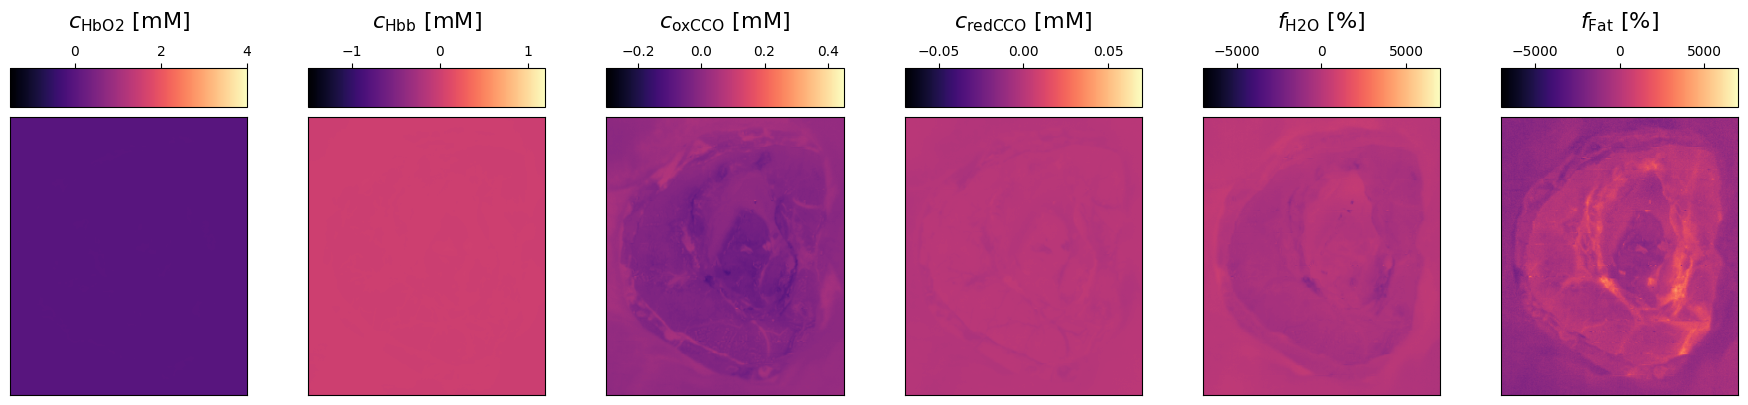

In [6]:
cfg = [
(0, r"$c_{\mathrm{HbO2}}\ [\mathrm{mM}]$", 1,-1.5, 4.0),
(1, r"$c_{\mathrm{Hbb}}\ [\mathrm{mM}]$", 1, -1.5, 1.2),
(2, r"$c_{\mathrm{oxCCO}}\ [\mathrm{mM}]$", 1, -0.3, 0.45),
(3, r"$c_{\mathrm{redCCO}}\ [\mathrm{mM}]$", 1, -0.07, 0.07),
(4, r"$f_{\mathrm{H2O}}\ [\%]$", 100, -7000, 7000),
(5, r"$f_{\mathrm{Fat}}\ [\%]$", 100, -7000, 7000),
]

cmap = plt.cm.magma.copy()
cmap.set_bad("white")  # NaN varsa beyaz gösterir

fig, axs = plt.subplots(1, 6, figsize=(18, 4))
for ax, (i, title, scale, vmin, vmax) in zip(axs, cfg):
    x = maps[:, :, i] * scale
    im = ax.imshow(x, cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks([]); ax.set_yticks([])

    cax = make_axes_locatable(ax).append_axes("top", size="14%", pad=0.10)
    cax.set_title(title, fontsize=16, pad=12)
    cb = plt.colorbar(im, cax=cax, orientation="horizontal")
    cax.xaxis.set_ticks_position("top")

plt.tight_layout()
plt.show()

Common samples:
['008-01', '008-02', '012-01', '012-02', '015-01', '016-04', '016-05', '020-01', '025-02']


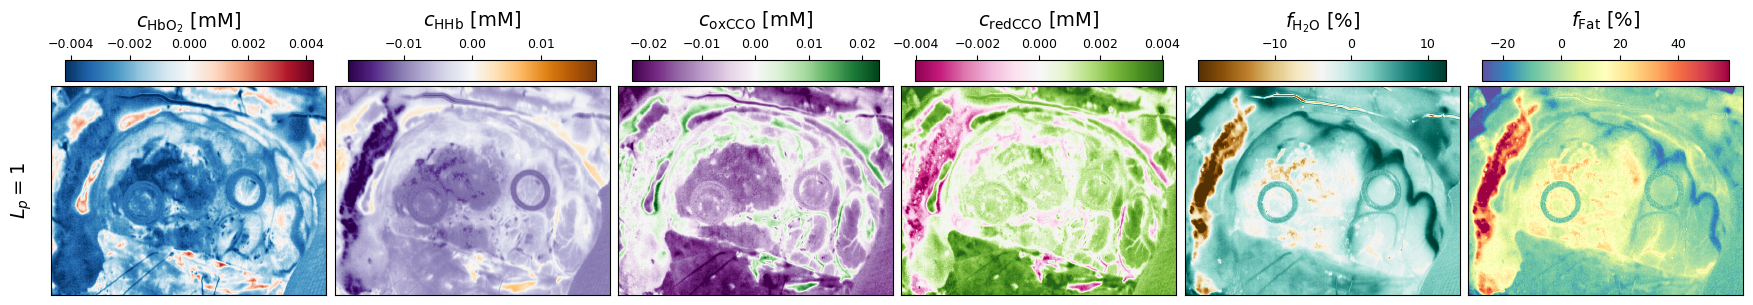

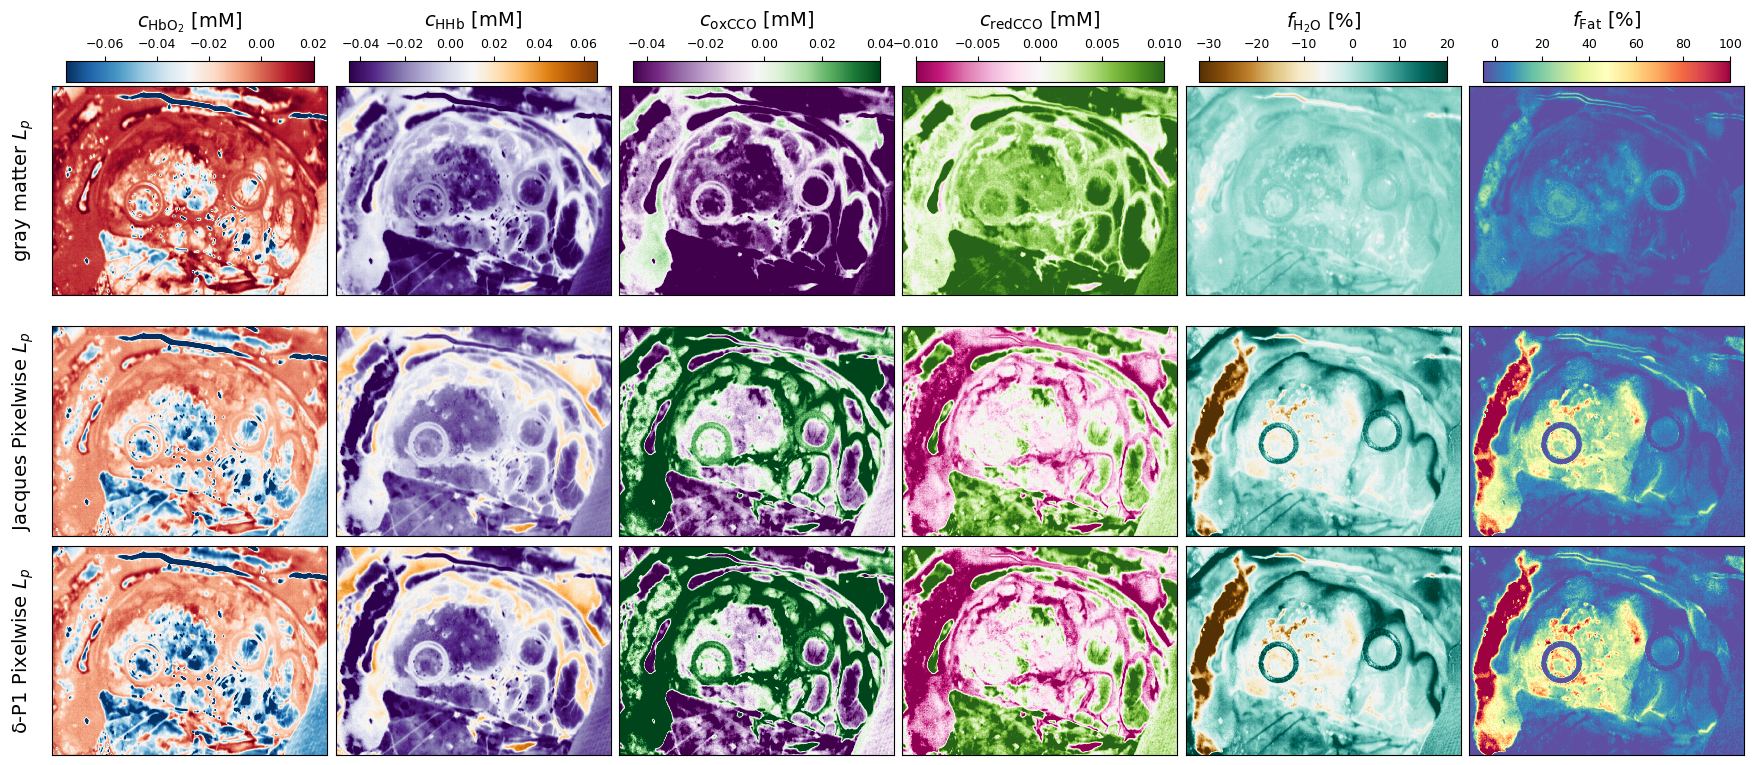

In [30]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# ------------------------------------------------------------
# 1) Configure the 4 methods / folders
# ------------------------------------------------------------
METHODS = [
    {
        "name": "$L_p = 1$",
        "dir": Path("/home/cihank/hsi-biopsy/results/helicoid_molecular_maps/reference_params"),
    },
    {
        "name": "gray matter $L_p$",
        "dir": Path("/home/cihank/hsi-biopsy/results/helicoid_variable_pl/reference_params"),
    },
    {
        "name": "Jacques Pixelwise $L_p$",
        "dir": Path("/home/cihank/hsi-biopsy/results/helicoid_jacques_pixelwise/reference_params"),
    },
    {
        "name": "δ-P1 Pixelwise $L_p$",
        "dir": Path("/home/cihank/hsi-biopsy/results/helicoid_delta_p1_bootstrapped/reference_params"),
    },
]

# Choose which sample to plot.
# Set to None to automatically use the first common sample.
SAMPLE_ID = "015-01"
# SAMPLE_ID = None


# ------------------------------------------------------------
# 2) Coefficient indices
# ------------------------------------------------------------
HBO2 = 0
HB = 1
COXA = 2
CREDA = 3
C_OXY = 4
C_RED = 5
B_OXY = 6
B_RED = 7
WATER = 8
FAT = 9


# ------------------------------------------------------------
# 3) Plot configuration: 6 chromophore columns
# ------------------------------------------------------------
# Important:
# I use COXA and CREDA for oxCCO/redCCO.
# Your old plotting code used indices 4 and 5, but those correspond to C_OXY/C_RED.
# ------------------------------------------------------------
# 3) Chromophore configuration
# ------------------------------------------------------------
# remove vmax and vmin for the plots to be auto-scaled
CHROMOPHORES = [
    {
        "idx": HBO2,
        "title": r"$c_{\mathrm{HbO_2}}\ [\mathrm{mM}]$",
        "scale": 1,
        "cmap": "RdBu_r",
        "vmin": -0.075,
        "vmax": 0.02,
    },
    {
        "idx": HB,
        "title": r"$c_{\mathrm{HHb}}\ [\mathrm{mM}]$",
        "scale": 1,
        "cmap": "PuOr_r",
        "vmin": -0.045,
        "vmax": 0.066,

    },
    {
        "idx": COXA,
        "title": r"$c_{\mathrm{oxCCO}}\ [\mathrm{mM}]$",
        "scale": 1,
        "cmap": "PRGn",
        "vmin": -0.045,
        "vmax": 0.04,
    },
    {
        "idx": CREDA,
        "title": r"$c_{\mathrm{redCCO}}\ [\mathrm{mM}]$",
        "scale": 1,
        "cmap": "PiYG",
        "vmin": -0.01,
        "vmax": 0.01,
    },
    {
        "idx": WATER,
        "title": r"$f_{\mathrm{H_2O}}\ [\%]$",
        "scale": 1,
        "cmap": "BrBG",
        "vmin": -32,
        "vmax": 20,
    },
    {
        "idx": FAT,
        "title": r"$f_{\mathrm{Fat}}\ [\%]$",
        "scale": 1,
        "cmap": "Spectral_r",
        "vmin": -5,
        "vmax": 100,
    },
]


# ------------------------------------------------------------
# 4) Helper functions
# ------------------------------------------------------------
from matplotlib.colors import TwoSlopeNorm, Normalize

DIVERGING_CMAPS = {"RdBu_r", "PuOr_r", "PRGn", "PiYG"}  # center these at 0

def compute_column_norms(
    results_by_method: dict[str, dict[str, np.ndarray]],
    sample_id: str,
    pct: tuple[float, float] = (1, 99),
):
    """Compute one shared vmin/vmax (or a zero-centered norm) per chromophore,
    using data from ALL methods for this sample so rows are directly comparable."""
    method_names = list(results_by_method.keys())
    norms = {}

    for cfg in CHROMOPHORES:
        idx, scale, cmap_name = cfg["idx"], cfg["scale"], cfg["cmap"]

        all_vals = []
        for method_name in method_names:
            coefs = results_by_method[method_name][sample_id]
            img = coefs[:, :, idx].astype(float) * scale
            all_vals.append(img[np.isfinite(img)])
        all_vals = np.concatenate(all_vals)

        vmin, vmax = np.nanpercentile(all_vals, pct)

        if cmap_name in DIVERGING_CMAPS:
            # symmetric around zero so the diverging colormap is meaningful
            vabs = max(abs(vmin), abs(vmax))
            norms[idx] = TwoSlopeNorm(vmin=-vabs, vcenter=0.0, vmax=vabs)
        else:
            norms[idx] = Normalize(vmin=vmin, vmax=vmax)

    return norms

def load_coef_lists(base_dir: Path) -> dict[str, np.ndarray]:
    base_dir = Path(base_dir)
    coef_files = sorted(base_dir.glob("*_coef_list.npy"))

    if not coef_files:
        raise FileNotFoundError(f"No *_coef_list.npy files found in: {base_dir}")

    coef_lists = {}

    for file_path in coef_files:
        sample_id = file_path.stem.replace("_coef_list", "")
        coef_lists[sample_id] = np.load(file_path, allow_pickle=True)

    return coef_lists


def get_common_samples(results_by_method: dict[str, dict[str, np.ndarray]]) -> list[str]:
    sample_sets = [set(result.keys()) for result in results_by_method.values()]
    common_samples = sorted(set.intersection(*sample_sets))

    if not common_samples:
        raise ValueError("No common sample IDs found across the 4 method folders.")

    return common_samples


def plot_4x6_maps(
    results_by_method: dict[str, dict[str, np.ndarray]],
    sample_id: str,
    save_path: str | Path | None = None,
    col_width: float = 3.0,     # width per column, inches
    cbar_height: float = 0.45,  # extra height reserved for top-row colorbars
    hspace: float = 0.03,       # vertical gap between rows (fraction of row height)
    wspace: float = 0.03,       # horizontal gap between columns
    use_normalized_scaling: bool = False,  # <-- new: True = use compute_column_norms, False = fixed vmin/vmax
):
    method_names = list(results_by_method.keys())
    n_rows = len(method_names)
    n_cols = len(CHROMOPHORES)

    # --- Determine the true image aspect ratio from the actual data ---
    sample_coefs = results_by_method[method_names[0]][sample_id]
    img_h, img_w = sample_coefs.shape[0], sample_coefs.shape[1]
    aspect = img_h / img_w  # height / width

    row_height = col_width * aspect  # this makes each cell's natural size == image's own aspect

    # First row gets extra height for the colorbar/title strip
    height_ratios = [row_height + cbar_height] + [row_height] * (n_rows - 1)
    fig_width = col_width * n_cols
    fig_height = sum(height_ratios)

    fig, axs = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_width, fig_height),
        gridspec_kw={"height_ratios": height_ratios, "hspace": hspace, "wspace": wspace},
    )
    axs = np.asarray(axs).reshape(n_rows, n_cols)
    column_norms = compute_column_norms(results_by_method, sample_id)  # only used if use_normalized_scaling=True

    for row_idx, method_name in enumerate(method_names):
        coefs = results_by_method[method_name][sample_id]

        for col_idx, cfg in enumerate(CHROMOPHORES):
            ax = axs[row_idx, col_idx]
            img = coefs[:, :, cfg["idx"]].astype(float) * cfg["scale"]

            cmap = plt.get_cmap(cfg["cmap"]).copy()
            cmap.set_bad("white")

            if use_normalized_scaling:
                im = ax.imshow(img, cmap=cmap, norm=column_norms[cfg["idx"]])
            else:
                im = ax.imshow(img, cmap=cmap, vmin=cfg["vmin"], vmax=cfg["vmax"])
            ax.set_aspect("equal")

            # Column title + colorbar only on first row
            if row_idx == 0:
                cax = inset_axes(
                                    ax,
                                    width="90%",      # colorbar yatay uzunluğu
                                    height="10%",      # colorbar yüksekliği
                                    loc="upper center",
                                    bbox_to_anchor=(0, 0.12, 1, 1),
                                    bbox_transform=ax.transAxes,
                                    borderpad=0,
                                )
                cax.set_title(cfg["title"], fontsize=14, pad=8)
                cb = plt.colorbar(im, cax=cax, orientation="horizontal")
                cax.xaxis.set_ticks_position("top")
                cax.tick_params(labelsize=9)

            # Method names on the left
            if col_idx == 0:
                ax.set_ylabel(
                    method_name,
                    fontsize=14,
                    rotation=90,
                    labelpad=12,
                )

            ax.set_xticks([])
            ax.set_yticks([])

    fig.subplots_adjust(left=0.05, right=0.99, top=0.97, bottom=0.02,
                         hspace=hspace, wspace=wspace)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# ------------------------------------------------------------
# 5) Load all 4 folders
# ------------------------------------------------------------
results_by_method = {}

for method in METHODS:
    method_name = method["name"]
    method_dir = method["dir"]

    results_by_method[method_name] = load_coef_lists(method_dir)

common_samples = get_common_samples(results_by_method)

print("Common samples:")
print(common_samples)

if SAMPLE_ID is None:
    SAMPLE_ID = common_samples[0]

if SAMPLE_ID not in common_samples:
    raise ValueError(
        f"SAMPLE_ID={SAMPLE_ID!r} is not available in all folders. "
        f"Common samples are: {common_samples}"
    )




# ------------------------------------------------------------
# 7) Final plots — Lp=1 separately from the other 3 methods
# ------------------------------------------------------------
LP1_NAME = "$L_p = 1$"

lp1_results = {LP1_NAME: results_by_method[LP1_NAME]}
other_results = {
    name: coef_dict
    for name, coef_dict in results_by_method.items()
    if name != LP1_NAME
}

# Lp = 1: use normalized (percentile-clipped / zero-centered) scaling
plot_4x6_maps(
    results_by_method=lp1_results,
    sample_id=SAMPLE_ID,
    save_path=None,
    use_normalized_scaling=True,
)

# Other 3 methods: keep the fixed vmin/vmax from CHROMOPHORES
plot_4x6_maps(
    results_by_method=other_results,
    sample_id=SAMPLE_ID,
    save_path=None,
    use_normalized_scaling=False,
)


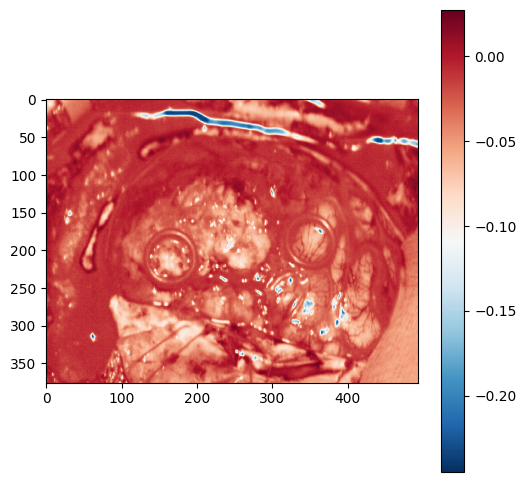

In [8]:
# plot delta_p1 hbo2
delta_p1_hbo2 = results_by_method["δ-P1 Pixelwise $L_p$"][SAMPLE_ID][:, :, HBO2]
plt.figure(figsize=(6, 6))
plt.imshow(delta_p1_hbo2, cmap="RdBu_r")
plt.colorbar()

Mean difference between Jacques and gray matter PL for HbO2: 3.903444222945887


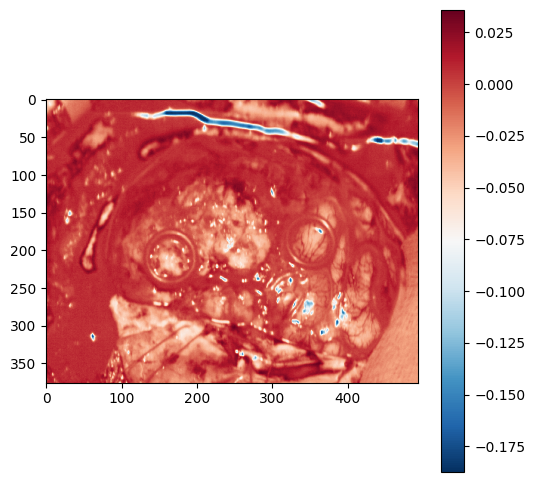

In [9]:
gray_matter_hbo2 = results_by_method["gray matter $L_p$"][SAMPLE_ID][:, :, HBO2]
plt.figure(figsize=(6, 6))
plt.imshow(gray_matter_hbo2, cmap="RdBu_r")
plt.colorbar()
print("Mean difference between Jacques and gray matter PL for HbO2:", np.nanmean(delta_p1_hbo2 - gray_matter_hbo2)/np.nanmean(gray_matter_hbo2))